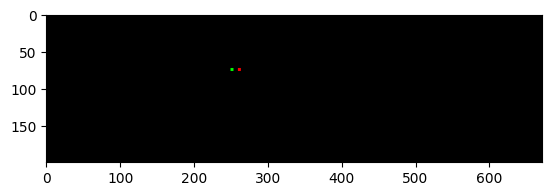

In [19]:
# Creates dataset files
import numpy as np
from matplotlib import pyplot as plt

# Input data
shape  = (100, 1, 28, 28)
images = np.ones(shape=shape, dtype=np.float32)

labels = np.zeros(shape=(shape[0], 1, 10), dtype=np.int64)
labels[:, 0, 0] = 1

# Region File
region_file = np.load('../source/Assets/custom_mask_single.npy')
region_file = region_file[0].squeeze()

# circular shift amount (right shift)
shift_amount = 10
region_file_shifted = np.roll(region_file, shift_amount)

# Visualize the region file
# [H, W] -> [H, W, 3]
Z = np.zeros(shape=(region_file_shifted.shape[0], region_file_shifted.shape[1], 3), dtype=np.float32)
Z[:, :, 0] = region_file_shifted  # Red channel
Z[:, :, 1] = region_file  # Green channel
plt.imshow(Z)
plt.show()

# Save the images and labels as .npy files
# -- Images
#       Training_Dataset.npy
#       Validation_Dataset.npy
#       Testing_Dataset.npy
# -- Labels
#       Training_Dataset.npy
#       Validation_Dataset.npy
#       Testing_Dataset.npy
for dataset_type in ['Training', 'Validation', 'Testing']:
    np.save(f'./Images/{dataset_type}_Dataset.npy', images)
    np.save(f'./Labels/{dataset_type}_Dataset.npy', labels)

# Save the region file as target.npy
np.save('./target.npy', region_file_shifted)